In [ ]:
# Important Imports, System Parameters and Drive Parameters:
import dynamiqs as dq
import jax.numpy as jnp

from pathlib import Path
import json
import matplotlib.pyplot as plt 

dq.set_precision('double')  # 'single' by default

# System Parameters:
params = {
    "w_c" : 3300.0, 
    "Kappa_c" : 0.0000207,  
    "Xcc" : 164.0,

    "w_a" : 4620.0,
    "Kappa_a" : 2.0,
    "Xaa" : 0.0000001,
}

# Drive Parameters:
params["Delta_c"] = 0.0
params["drive_amplitude_c"] = 10.0

params["Delta_a"] = 1
params["drive_amplitude_a"] = 4.0



|██████████| 100.0% ◆ elapsed 177.83ms ◆ remaining 0.00ms 

==== MESolveResult ====
Method  : Tsit5
Infos   : 7517 steps (6261 accepted, 1256 rejected)
States  : QArray complex128 (1, 2, 2) | 0.1 Kb
Expects : Array complex128 (2, 10000) | 312.5 Kb



/var/folders/gp/q1qf87r11d76bkk9mjsd9kfh0000gr/T/ipykernel_95572/2892149175.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


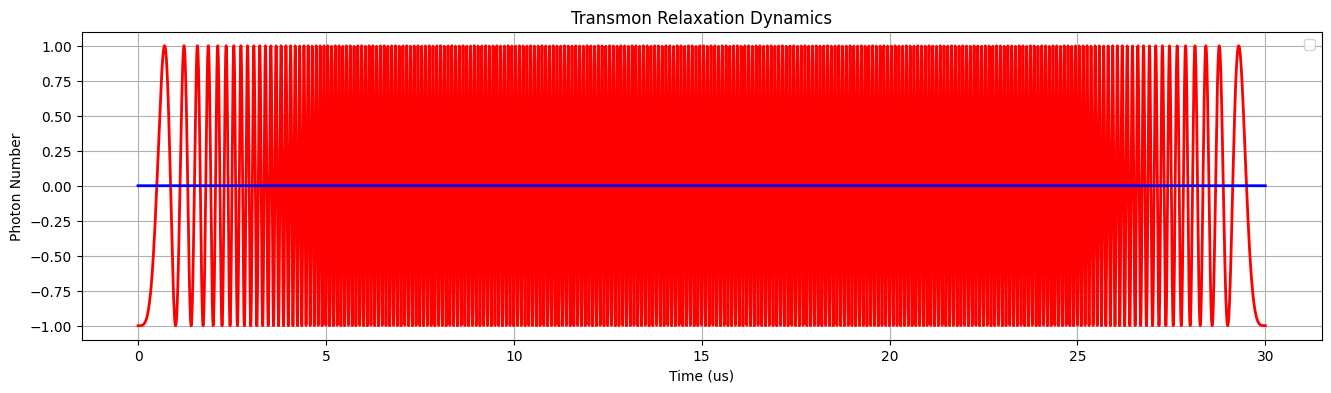

In [153]:
# Defining the System :
Nc = 2
c = dq.destroy(Nc)
Numc = c.dag() @ c
I = dq.eye(Nc)

# Defining the Hamiltonian and the Collapse Operators and Observables:
H0 = params["Delta_c"] * Numc + (params["Xcc"] / 2) * Numc @ (Numc - I)
H0 = -0.5 * params["Delta_c"] * dq.sigmaz() 

# 1. Define the time-dependent scalar function (the envelope)
# 1. Define the time-dependent scalar function (Trapezoidal Envelope)
def rabi_envelope(t):
    amp = params["drive_amplitude_c"]
    ramp_time = 5.0
    total_time = 30.0  # Set this to the total length of your pulse/simulation
    
    # Rising line: goes from 0 to 1 between t=0 and t=5
    ramp_up = t / ramp_time
    
    # Falling line: goes from 1 to 0 between t=95 and t=100
    ramp_down = (total_time - t) / ramp_time
    
    # Combine them: take the lowest value, chop off the top at 1.0, and prevent it from going below 0.0
    normalized_envelope = jnp.clip(jnp.minimum(ramp_up, ramp_down), 0.0, 1.0)
    
    return amp * normalized_envelope

# 2. Define the static operator for the transmon drive (without the amplitude)
Hdrive_c_op = -2 * jnp.pi * 0.5 * (c + c.dag())
Hdrive_c_op = -2 * jnp.pi * 0.5 * dq.sigmax()

# 3. Create the modulated TimeQArray for the transmon drive
Hdrive_c_td = dq.modulated(rabi_envelope, Hdrive_c_op)

H = H0 + Hdrive_c_td

Dissipators = [jnp.sqrt(params["Kappa_c"]) * dq.sigmam()]

Observables = [dq.sigmaz(), dq.sigmax()]

# Scope of Simulation :

Rho0 = dq.ground_dm()
times = jnp.linspace(0, 30, 10000)
Method = dq.method.Tsit5(rtol = 1e-6, atol = 1e-8, max_steps = 5000000)
options = dq.options.Options(save_states=False)
#Method = dq.method.Expm()

# Running the Simulation :
result = dq.mesolve(H, Dissipators, Rho0, tsave=times, exp_ops=Observables, method=Method,options=options)  
print(result)
# Analyzing the Results :
#states_array = [rho.to_jax() for rho in result.states]
#Populattion_cavity = jnp.array([jnp.diag(rho).real for rho in states_array])

fig, ax = plt.subplots(figsize=(16,4))
ax.plot(times, result.expects[0].real, linewidth=2, color = "r")
ax.plot(times, result.expects[1].real, linewidth=2, color = "b")
ax.set_xlabel("Time (us)")
ax.set_ylabel("Photon Number")
ax.set_title("Transmon Relaxation Dynamics")
ax.grid()
ax.legend()



|██████████| 100.0% ◆ elapsed 247.99ms ◆ remaining 0.00ms  
/var/folders/gp/q1qf87r11d76bkk9mjsd9kfh0000gr/T/ipykernel_95572/3672022024.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


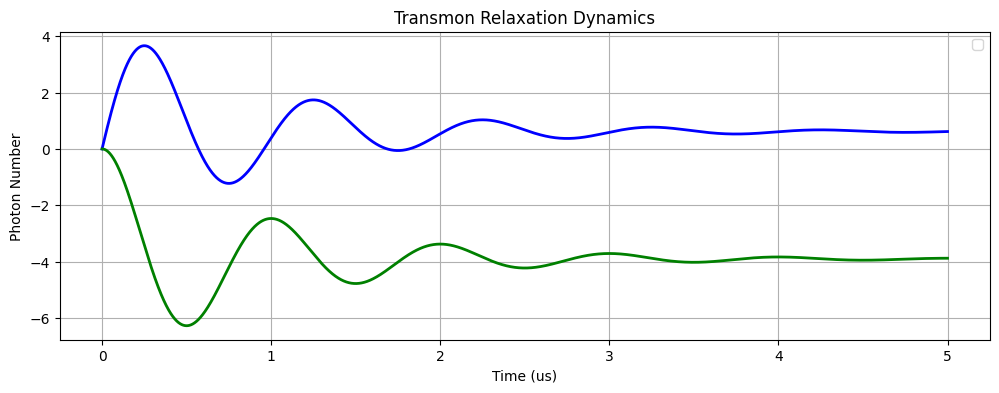

In [154]:
# Defining the System :
Na = 45
a = dq.destroy(Na)
Numa = a.dag() @ a
I = dq.eye(Na)

H = -2 * jnp.pi * params["Delta_a"] * Numa + (params["Xaa"] / 2) * Numa @ (Numa - I) + 2 * jnp.pi * 1j * params["drive_amplitude_a"] * (a.dag()-a)
Observables = [Numa, a + a.dag(), 1j * (a - a.dag())]
Dissipators = [jnp.sqrt(params["Kappa_a"]) * a]

Rho0 = dq.coherent_dm(Na,0.0)

times = jnp.linspace(0, 5, 10000)

result = dq.mesolve(H, Dissipators, Rho0, tsave=times, exp_ops=Observables, method=Method)

#dq.plot.wigner_gif(result.states, fps=5)
fig, ax = plt.subplots(figsize=(12,4))
#ax.plot(times, result.expects[0].real, linewidth=2, color = "r")
ax.plot(times, result.expects[1].real, linewidth=2, color = "b")
ax.plot(times, result.expects[2].real, linewidth=2, color = "g")
ax.set_xlabel("Time (us)")
ax.set_ylabel("Photon Number")
ax.set_title("Transmon Relaxation Dynamics")
ax.grid()
ax.legend()


|██████████| 100.0% ◆ elapsed 245.16ms ◆ remaining 0.00ms  
/var/folders/gp/q1qf87r11d76bkk9mjsd9kfh0000gr/T/ipykernel_95572/3716816025.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


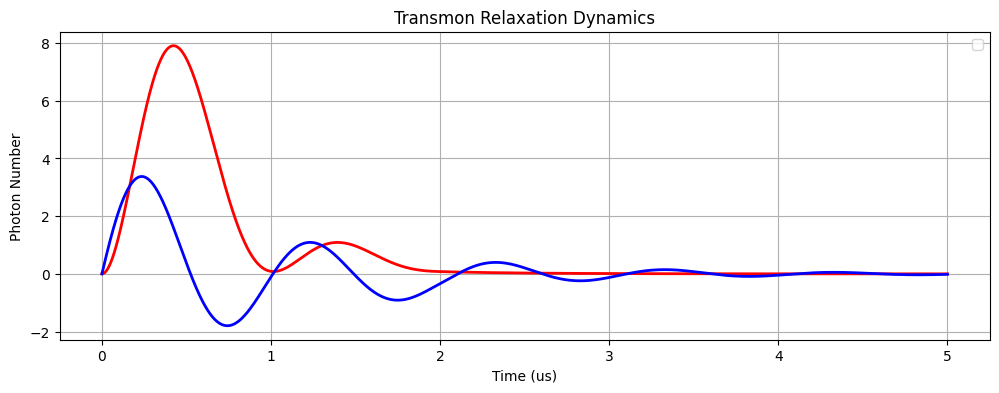

In [155]:
# Ramping up the drive :
# 1. Define the time-dependent scalar function (the envelope)
# 1. Define the time-dependent scalar function (Trapezoidal Envelope)
def rabi_envelope(t):
    amp = params["drive_amplitude_a"]
    ramp_time = 2.0
    total_time = 10.0  # Set this to the total length of your pulse/simulation
    
    # Rising line: goes from 0 to 1 between t=0 and t=5
    ramp_up = t / ramp_time
    
    # Falling line: goes from 1 to 0 between t=95 and t=100
    ramp_down = (total_time - t) / ramp_time
    
    # Combine them: take the lowest value, chop off the top at 1.0, and prevent it from going below 0.0
    normalized_envelope = jnp.clip(jnp.minimum(ramp_up, ramp_down), 0.0, 1.0)
    
    return amp * normalized_envelope

# 2. Define the static operator for the transmon drive (without the amplitude)
Hdrive_a_op = -2 * jnp.pi* 1j * (a.dag()-a)


# 3. Create the modulated TimeQArray for the transmon drive
Hdrive_a_td = dq.modulated(rabi_envelope, Hdrive_a_op)

H = H + Hdrive_a_td

result = dq.mesolve(H, Dissipators, Rho0, tsave=times, exp_ops=Observables, method=Method)

#dq.plot.wigner_gif(result.states, fps=5)
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(times, result.expects[0].real, linewidth=2, color = "r")
ax.plot(times, result.expects[1].real, linewidth=2, color = "b")
ax.set_xlabel("Time (us)")
ax.set_ylabel("Photon Number")
ax.set_title("Transmon Relaxation Dynamics")
ax.grid()
ax.legend()